# PLM Dual Threshold
- `dftest_export.csv`
- `plm_dual_threshold.py`

In [1]:
import importlib  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plm_dual_threshold as plm_dt

importlib.reload(plm_dt)


<module 'plm_dual_threshold' from '/home/cyuhao/data/plm_dual_threshold.py'>

In [2]:
dftest = pd.read_csv('dftest_export.csv')
print('dftest shape:', dftest.shape)
dftest.head(3)


/tmp/ipykernel_3893394/4031810077.py:1: DtypeWarning: Columns (0: co_applicant_age) have mixed types. Specify dtype option on import or set low_memory=False.
  dftest = pd.read_csv('dftest_export.csv')


dftest shape: (5291146, 76)


,interest_rate,combined_loan_to_value_ratio,property_value,income,applicant_age_above_62,census_tract,county_code,state_code,loan_term,conforming_loan_limit,...,effective_rate,cltv_gt_80,monthly_payment,property_value_est,pmi_amount_monthly,pmi_months,total_pmi_paid,total_principal_interest_paid,total_repayment_including_pmi,y
0,12.59,44.37,695000.0,124.0,NaN,9.170194e+09,9170.0,CT,360.0,C,...,12.59,0,913.109235,191570.881226,0.0,0.0,0.0,328719.324519,328719.0,12.59
1,9.34,50.55,865000.0,113.0,NaN,4.207101e+10,42071.0,PA,360.0,C,...,9.34,0,1036.506893,247279.920870,0.0,0.0,0.0,373142.481330,373142.0,9.34
2,10.09,22.22,225000.0,34.0,NaN,4.205796e+10,42057.0,PA,360.0,C,...,10.09,0,486.326241,247524.752475,0.0,0.0,0.0,175077.446925,175077.0,10.09


In [3]:
# --- Unified configuration -------------------------------------------------

# Running variables and thresholds
SCORE1_COL = "combined_loan_to_value_ratio"
SCORE2_COL = "loan_amount"
C1 = 80.1        # CLTV threshold
C2 = 766550      # conforming loan limit

# Outcome construction
PMI_RATE = 0.008
CLTV_FLAG_COL = "cltv_gt_80"
dftest[CLTV_FLAG_COL] = (dftest[SCORE1_COL] > 80).astype(int)
dftest["y"] = dftest["interest_rate"] + 100 * PMI_RATE * dftest[CLTV_FLAG_COL]
Y_COL = "y"
PLOT_Y_COL = "interest_rate"

# Cost used in ewA_dual utility calculation
COST = 0.4

# PLM hyperparameters
KN = 6           # number of knots in each dimension
BWF = 1.0        # bandwidth multiplier
SUPPORT_PCT = 10
FIT_WINDOW1 = 10
FIT_WINDOW2 = 100000

# Control variables
X_COL = [
    "income", "dti_num",
    "property_value", "loan_term",
    "derived_ethnicity", "derived_race", "derived_sex",
    "derived_loan_product_type", "occupancy_type", "construction_method",
    "loan_type", "loan_purpose", "lien_status",
    "business_or_commercial_purpose", "open_end_line_of_credit",
    "hoepa_status", "reverse_mortgage",
    "activity_year", "county_code",
    "tract_population", "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income", "tract_to_msa_income_percentage",
    "tract_owner_occupied_units", "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units",
]

print("COST =", COST)
print("Outcome definition: interest_rate + 100 * PMI_RATE * cltv_gt_80")
print("Mean of y:", round(dftest[Y_COL].mean(), 4))


COST = 0.4
Outcome definition: interest_rate + 100 * PMI_RATE * cltv_gt_80
Mean of y: 7.4595


In [4]:
import numpy as np
import pandas as pd

def check_dftest_for_plm(dftest, X_col, y_col, score1_col, score2_col):
    cols = [y_col, score1_col, score2_col] + [c for c in X_col if c in dftest.columns]
    d = dftest[cols].copy()

    print("shape:", d.shape)

    for c in [y_col, score1_col, score2_col]:
        s = pd.to_numeric(d[c], errors="coerce")
        print(f"\n[{c}]")
        print("  finite:", np.isfinite(s).sum(), "/", len(s))
        print("  na after numeric:", s.isna().sum())
        if s.notna().any():
            print("  min/max:", float(s.min()), float(s.max()))

    avail = [c for c in X_col if c in dftest.columns]
    missing = [c for c in X_col if c not in dftest.columns]
    print("\nX cols found:", len(avail))
    print("X cols missing:", missing[:20])

    xdf = dftest[avail].copy()
    cat_cols = xdf.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in xdf.columns if c not in cat_cols]

    for c in num_cols:
        xdf[c] = pd.to_numeric(xdf[c], errors="coerce")

    if cat_cols:
        xdf = pd.get_dummies(xdf, columns=cat_cols, drop_first=True, dummy_na=False)

    for c in xdf.columns:
        xdf[c] = pd.to_numeric(xdf[c], errors="coerce")

    x = xdf.to_numpy(dtype=float)

    print("\nX matrix diagnostics")
    print("  shape:", x.shape)
    print("  finite all:", np.isfinite(x).all())
    print("  non-finite cols:", np.where(~np.isfinite(x).all(axis=0))[0][:20])

    col_nan_ratio = np.isnan(x).mean(axis=0)
    print("  cols with any nan:", int((col_nan_ratio > 0).sum()))
    print("  cols with >=20% nan:", int((col_nan_ratio >= 0.2).sum()))

    std = np.nanstd(x, axis=0)
    print("  constant cols:", np.where(std <= 1e-8)[0][:20])

    finite_x = x[np.isfinite(x)]
    if finite_x.size:
        print("  max abs finite x:", np.max(np.abs(finite_x)))
        print("  #(|x| > 1e6):", int((np.abs(finite_x) > 1e6).sum()))

In [5]:
check_dftest_for_plm(
    dftest,
    X_col=X_COL,
    y_col=Y_COL,
    score1_col=SCORE1_COL,
    score2_col=SCORE2_COL
)

shape: (5291146, 29)

[y]
  finite: 5290845 / 5291146
  na after numeric: 301
  min/max: 0.0 60.0

[combined_loan_to_value_ratio]
  finite: 5291146 / 5291146
  na after numeric: 0
  min/max: 0.04 100.0

[loan_amount]
  finite: 5291146 / 5291146
  na after numeric: 0
  min/max: 5000.0 36405000.0

X cols found: 26
X cols missing: []


/tmp/ipykernel_3893394/1803412124.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = xdf.select_dtypes(include=["object", "category", "bool"]).columns.tolist()



X matrix diagnostics
  shape: (5291146, 41)
  finite all: False
  non-finite cols: [1 2 3]
  cols with any nan: 3
  cols with >=20% nan: 0
  constant cols: [13]
  max abs finite x: 2147483647.0
  #(|x| > 1e6): 425943


In [6]:
for c in X_COL:
    if c not in dftest.columns:
        continue
    
    s_raw = dftest[c]
    s_num = pd.to_numeric(s_raw, errors="coerce")
    
    print(f"\n=== {c} ===")
    print("raw dtype:", s_raw.dtype)
    print("raw NA:", s_raw.isna().sum())
    print("numeric NA:", s_num.isna().sum())
    
    bad = s_raw[s_num.isna() & s_raw.notna()]
    if len(bad) > 0:
        print("examples that became NaN:")
        print(bad.astype(str).value_counts().head(10))


=== income ===
raw dtype: float64
raw NA: 0
numeric NA: 0

=== dti_num ===
raw dtype: float64
raw NA: 183
numeric NA: 183

=== property_value ===
raw dtype: float64
raw NA: 231
numeric NA: 231

=== loan_term ===
raw dtype: float64
raw NA: 274
numeric NA: 274

=== derived_ethnicity ===
raw dtype: str
raw NA: 0
numeric NA: 5291146
examples that became NaN:
derived_ethnicity
Not Hispanic or Latino     3869735
Ethnicity Not Available     684279
Hispanic or Latino          585977
Joint                       151155
Name: count, dtype: int64

=== derived_race ===
raw dtype: str
raw NA: 0
numeric NA: 5291146
examples that became NaN:
derived_race
White                                        3633731
Race Not Available                            742881
Black or African American                     369572
Asian                                         363068
Joint                                         129381
American Indian or Alaska Native               31178
2 or more minority races          

In [7]:
y, x_mat, r1, r2, treated = plm_dt.prepare_data(
    dftest,
    X_COL,
    y_col=Y_COL,
    score1_col=SCORE1_COL,
    score2_col=SCORE2_COL,
    c1=C1,
    c2=C2,
    fit_window1=FIT_WINDOW1,
    fit_window2=FIT_WINDOW2,
)

cost = COST

print("Prepared data successfully.")
print("y shape:", y.shape)
print("x_mat shape:", x_mat.shape)
print("treated count:", int(treated.sum()))
print("control count:", int((~treated).sum()))



[0/3] Preparing data ...
  dropped 301 NA rows  →  n=5,290,845  [8.5s]
  window kept 102,729/5,290,845 rows (|r1|<=10, |r2|<=100000)  [8.9s]
  treated (AND): 7,436  control: 95,293  (7.2%)  [8.9s]
  X matrix: 102,729 x 39  [8.9s]
Prepared data successfully.
y shape: (102729,)
x_mat shape: (102729, 39)
treated count: 7436
control count: 95293


In [8]:
col = x_mat[:, 2]

print(np.unique(col)[:20])

[  5000. 115000. 195000. 205000. 215000. 235000. 275000. 285000. 315000.
 345000. 365000. 375000. 395000. 405000. 425000. 435000. 445000. 465000.
 475000. 515000.]


In [9]:
import numpy as np

print("y finite:", np.isfinite(y).all())
print("r1 finite:", np.isfinite(r1).all())
print("r2 finite:", np.isfinite(r2).all())
print("x_mat finite:", np.isfinite(x_mat).all())

print("x_mat shape:", x_mat.shape)
print("treated/control:", treated.sum(), (~treated).sum())

bad_cols = np.where(~np.isfinite(x_mat).all(axis=0))[0]
print("non-finite cols:", bad_cols[:20], "count=", len(bad_cols))

col_std = np.nanstd(x_mat, axis=0)
print("zero-std cols:", np.where(col_std == 0)[0][:20], "count=", np.sum(col_std == 0))

print("max abs x:", np.nanmax(np.abs(x_mat)))

y finite: True
r1 finite: True
r2 finite: True
x_mat finite: True
x_mat shape: (102729, 39)
treated/control: 7436 95293
non-finite cols: [] count= 0
zero-std cols: [13] count= 1
max abs x: 10505000.0


In [11]:
# --- Estimate ewA_dual -----------------------------------------------------
ewA_val, info = plm_dt.ewA_dual(
    y,
    x_mat,
    r1,
    r2,
    treated,
    kn=KN,
    bwf=BWF,
    support_pct=SUPPORT_PCT,
    cost=COST,
    fit_window1=FIT_WINDOW1,
    fit_window2=FIT_WINDOW2,
)

print("===============================")
print(f"ewA_dual  = {ewA_val:.6f}")
print(f"cost      = {COST}")
print(f"net gain  = {ewA_val - COST:.6f}  (ewA - cost)")
print(f"n_treated = {info['n_treated']:,}")
print(f"n_insupp  = {info['n_insupp']:,}")
print("===============================")



[1/3] First stage ...
  window kept 102,729/102,729 rows (|r1|<=10, |r2|<=100000)  [0.2s]
  after cleaning/windowing: n=80,303, p=38
  treated=6,563   control=73,740
  etaHat1  std=3.842  [1.5s]
  etaHat2  std=33199.881  [2.0s]

[2/3] TSplm2D on control ...
  [Con] basis 6x6=36  n=73,740  p=38  [0.2s]
  [Con] FWL step kept 38/38 x cols  [1.1s]
  [Con] h recovered on 36 basis terms  [1.1s]

[2/3] TSplm2D on treated ...
  [Tr] basis 6x6=36  n=6,563  p=38  [0.0s]
  [Tr] FWL step kept 38/38 x cols  [0.1s]
  [Tr] h recovered on 36 basis terms  [0.1s]

[3/3] Computing ewA_dual ...
  support: 727/6,563 treated obs (thr_tr=6.08e-06  thr_con=9.90e-07)  [3.6s]
  ewA_dual = -0.047023  [3.6s]
  net gain = -0.447023  (ewA - cost=0.4)  [3.6s]
ewA_dual  = -0.047023
cost      = 0.4
net gain  = -0.447023  (ewA - cost)
n_treated = 6,563
n_insupp  = 727


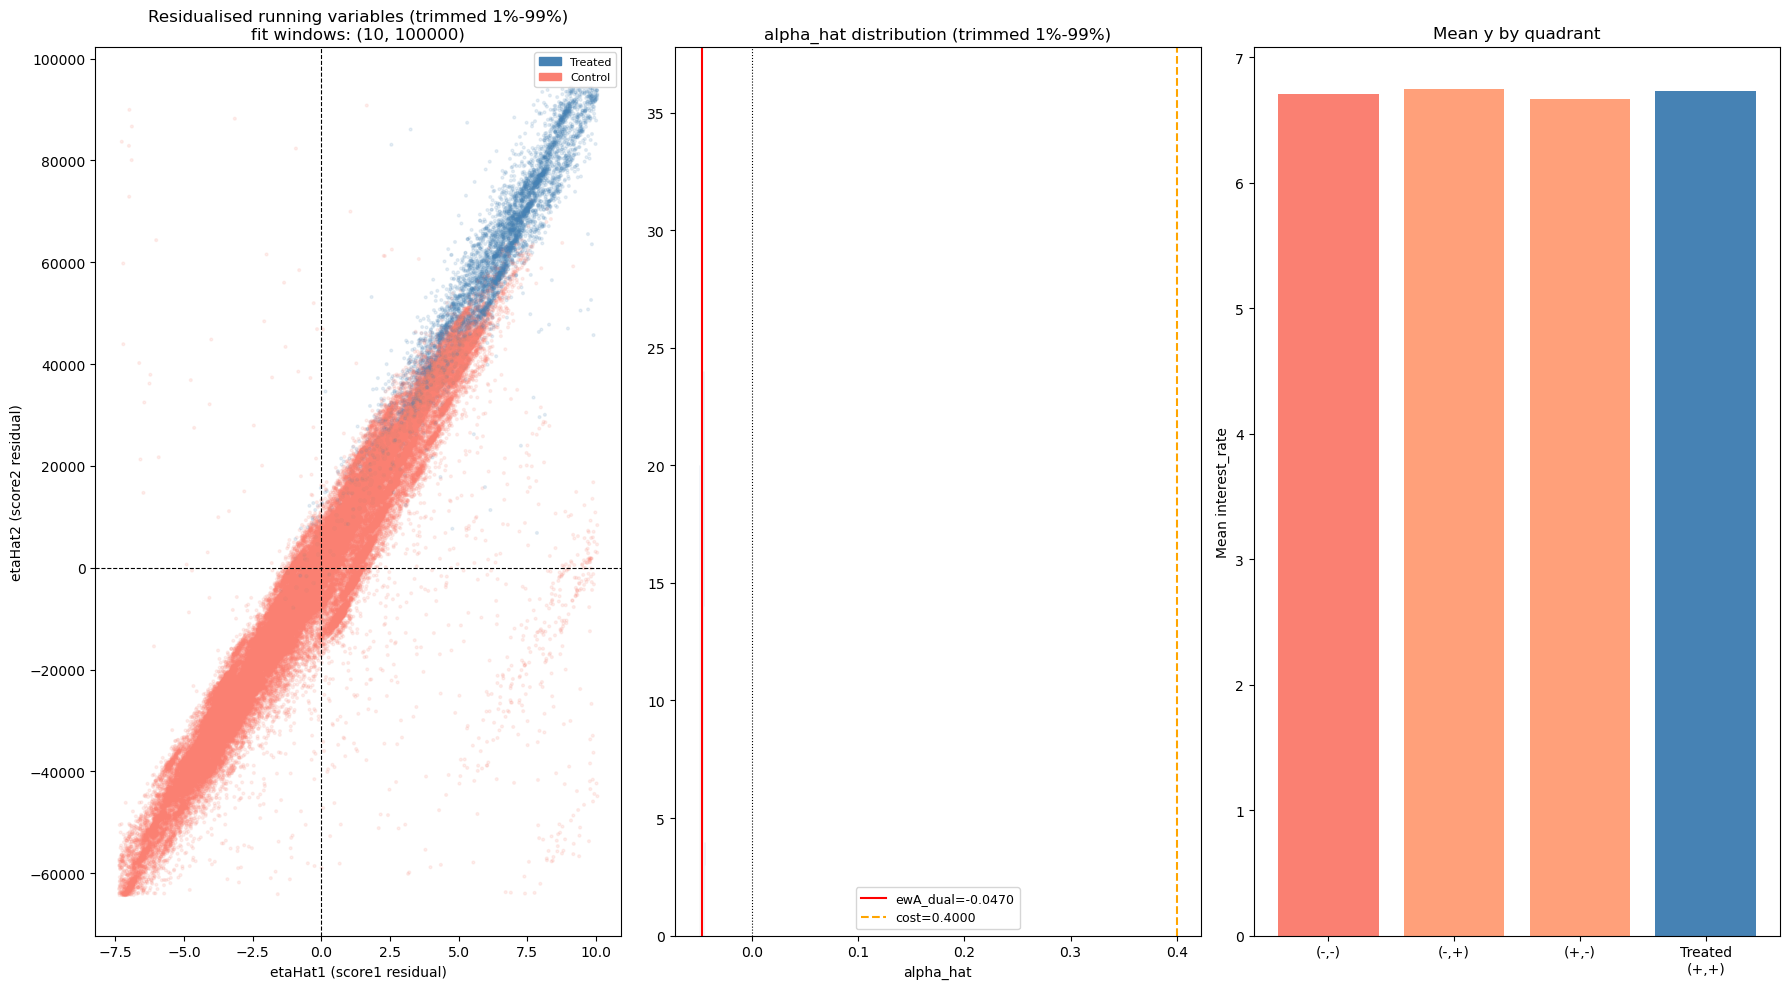

In [12]:
importlib.reload(plm_dt)
plm_dt.plot_results(
    info,
    dftest=dftest,
    score1_col=SCORE1_COL,
    score2_col=SCORE2_COL,
    c1=C1,
    c2=C2,
    y_col=PLOT_Y_COL,
    cost=COST,
)

plt.tight_layout()
plt.show()


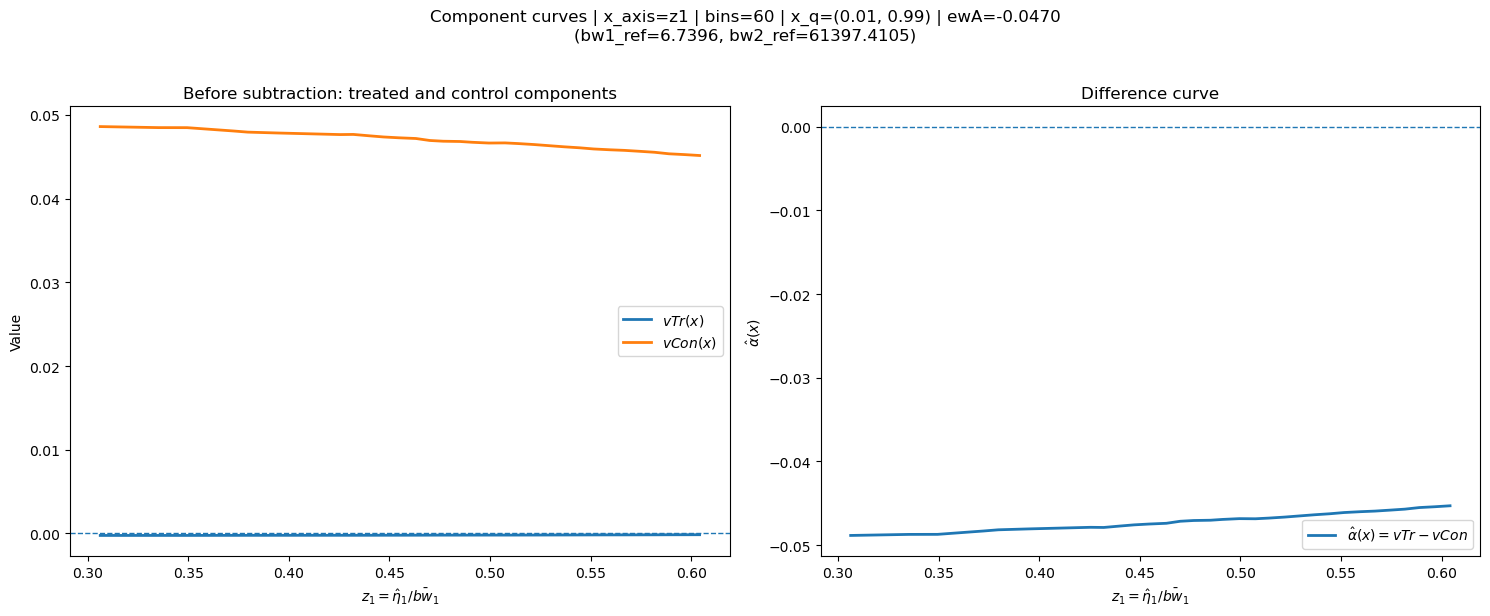

In [13]:
fig = plm_dt.plot_component_curves(
    info,
    x_axis="z1",  # options: "margin_std", "z1", or "z2"
    bins=60,
    smooth_window=5,
    x_q=(0.01, 0.99),
    min_bin_count=8,
    figsize=(15, 6),
)


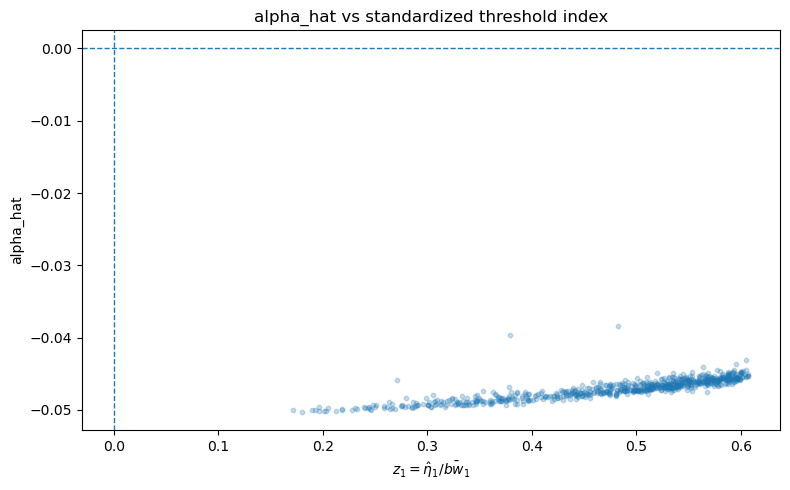

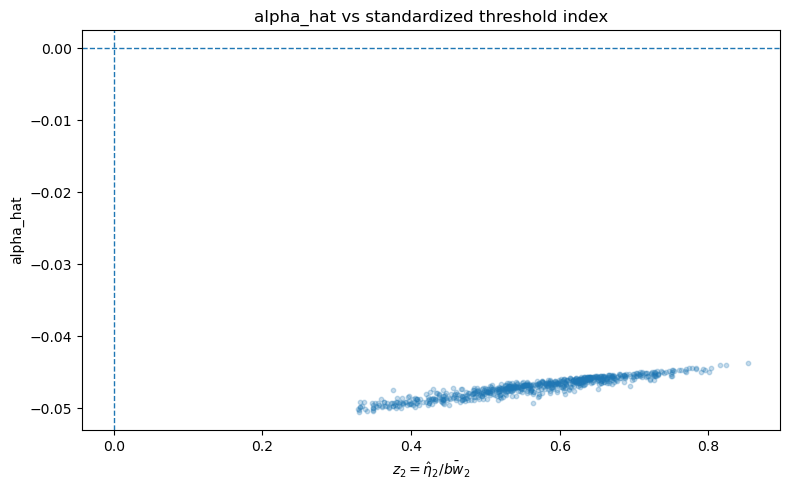

In [14]:
fig = plm_dt.plot_alpha_scatter_std(
    info,
    x_axis="z1",
    x_q=(0.01, 0.99),
    figsize=(8, 5),
)
fig = plm_dt.plot_alpha_scatter_std(
    info,
    x_axis="z2",
    x_q=(0.01, 0.99),
    figsize=(8, 5),
)

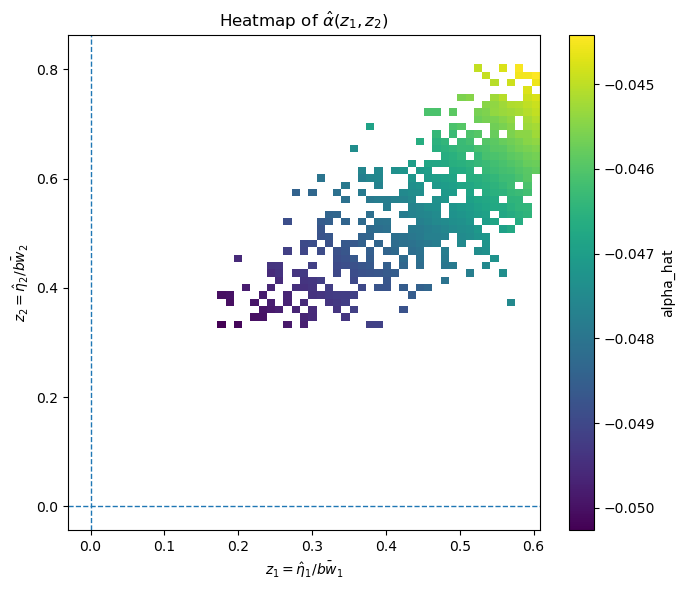

In [15]:
fig = plm_dt.plot_alpha_heatmap(
    info,
    gridsize=40,
    figsize=(7, 6)
)

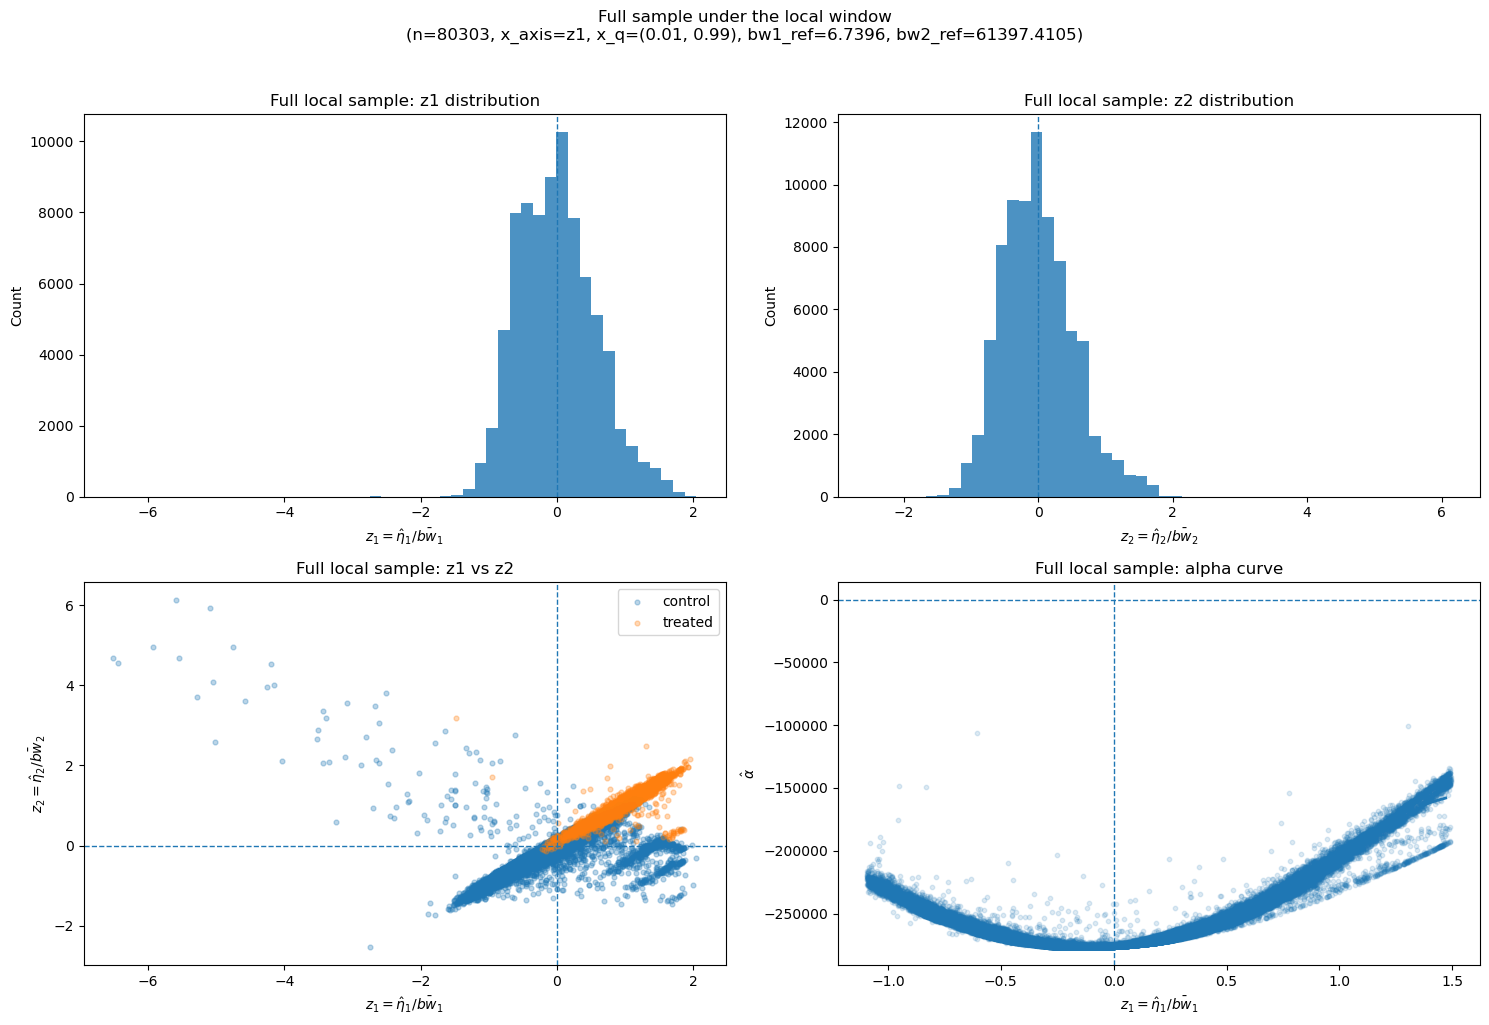

In [16]:
fig = plm_dt.plot_fullsample_local(
    info,
    x_axis="z1",
    bins=60,
    x_q=(0.01, 0.99),
    smooth_window=5,
    min_bin_count=10,
    figsize=(15, 10),
)
